# ChessFormer Interactive Play

This notebook lets you interact with the ChessFormer model to play chess or analyze positions.

In [9]:
import torch
import json
import chess
import chess.svg
import numpy as np
import os
import time
from IPython.display import SVG, display

from model import ChessModel
from tokenizer import tokenize_xfen, load_token_mapping
from game import ChessAI, ChessGame, setup_game_from_notebook
from config import DEVICE, MODEL_PARAMS, TOKEN_TO_ID_PATH, TOKENIZED_XFEN_FILE

In [10]:
# Fix paths to ensure we can find files regardless of notebook location
def resolve_path(relative_path):
    """Resolve a path relative to the project root directory"""
    # First try relative to current directory
    if os.path.exists(relative_path):
        return relative_path
    
    # Try one level up (if we're in chessformer/chessformer)
    parent_path = os.path.join('..', relative_path)
    if os.path.exists(parent_path):
        return parent_path
    
    # Try from project root assuming we're in a subdirectory of the project
    current_dir = os.getcwd()
    project_root = current_dir
    
    # Walk up directories until we find the project root (containing tmp directory)
    while project_root and not os.path.exists(os.path.join(project_root, 'tmp')):
        parent = os.path.dirname(project_root)
        if parent == project_root:  # Reached filesystem root without finding project root
            break
        project_root = parent
    
    full_path = os.path.join(project_root, relative_path)
    if os.path.exists(full_path):
        return full_path
        
    return relative_path  # Return original path if we couldn't resolve it

# Update the paths
TOKEN_TO_ID_PATH = resolve_path(TOKEN_TO_ID_PATH)
TOKENIZED_XFEN_FILE = resolve_path(TOKENIZED_XFEN_FILE)

print(f"Token mapping path: {TOKEN_TO_ID_PATH}")
print(f"Tokenized XFEN file path: {TOKENIZED_XFEN_FILE}")

Token mapping path: ../tmp/token_to_id.json
Tokenized XFEN file path: ../tmp/tokenized_xfen.txt


In [11]:
# Load token mapping first
try:
    token_to_id = load_token_mapping(TOKEN_TO_ID_PATH)
    id_to_token = {v: k for k, v in token_to_id.items()}
    print(f"Token mapping loaded successfully from {TOKEN_TO_ID_PATH}")
except FileNotFoundError:
    print(f"Error: Token mapping file not found at {TOKEN_TO_ID_PATH}")
    # Create the directory if it doesn't exist
    os.makedirs(os.path.dirname(TOKEN_TO_ID_PATH), exist_ok=True)
    
    # Fallback: Load directly from the JSON file we have in tmp folder
    fallback_path = '/Users/edouardalbert-roulhac/Documents/projects/chess/chessformer/tmp/token_to_id.json'
    with open(fallback_path, 'r') as f:
        token_to_id = json.load(f)
        id_to_token = {v: k for k, v in token_to_id.items()}
        print(f"Loaded token mapping from fallback location: {fallback_path}")

Token mapping loaded successfully from ../tmp/token_to_id.json


In [12]:
# Initialize the model
model = ChessModel(
    num_tokens=MODEL_PARAMS['num_tokens'],
    num_classes=MODEL_PARAMS['num_classes'],
    d_model=MODEL_PARAMS['d_model'],
    nhead=MODEL_PARAMS['nhead'],
    num_layers=MODEL_PARAMS['num_layers'],
    dropout=MODEL_PARAMS['dropout']
)

# Load the model weights if available
try:
    model_path = resolve_path('model_weights.pt')
    model.load_state_dict(torch.load(model_path))
    print(f"Model weights loaded successfully from {model_path}!")
except FileNotFoundError:
    print("No model weights found. Using untrained model.")

model.to(DEVICE)
model.eval()  # Set model to evaluation mode

No model weights found. Using untrained model.


ChessModel(
  (embedding): Embedding(258, 64, padding_idx=257)
  (layers): ModuleList(
    (0-3): 4 x TransformerLayer(
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadAttention(
        (q_proj): Linear(in_features=64, out_features=64, bias=True)
        (k_proj): Linear(in_features=64, out_features=64, bias=True)
        (v_proj): Linear(in_features=64, out_features=64, bias=True)
        (out_proj): Linear(in_features=64, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (dropout1): Dropout(p=0.1, inplace=False)
      (dropout2): Dropout(p=0.1, inplace=False)
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, element

## Quick Training

Train the model on a small batch of data to see how it improves.

In [15]:
# Custom dataset class to handle the specific format of the TOKENIZED_XFEN_FILE
class CustomChessDataset(torch.utils.data.Dataset):
    def __init__(self, file_path):
        # Check if file exists
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Dataset file not found: {file_path}")
            
        # Load all data from file
        with open(file_path, 'r') as file:
            self.data = []
            for line in file:
                try:
                    # Parse the JSON array
                    entry = json.loads(line.strip())
                    if isinstance(entry, list) and len(entry) == 4:
                        self.data.append(entry)
                except json.JSONDecodeError as e:
                    print(f"Error parsing line: {line.strip()[:50]}... - {str(e)}")
                    continue
        
        print(f"Loaded {len(self.data)} valid entries from {file_path}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        meta_tokens, pieces_tokens, squares_tokens, next_move = self.data[idx]
        sequence_tokens = meta_tokens + pieces_tokens
        squares_tokens_padded = [-1] * len(meta_tokens) + squares_tokens
        return {
            'sequence_tokens': torch.tensor(sequence_tokens, dtype=torch.long),
            'squares_tokens': torch.tensor(squares_tokens_padded, dtype=torch.long),
            'next_move': torch.tensor(next_move, dtype=torch.long),
        }

# Custom collate function
def custom_collate_fn(batch):
    sequence_tokens = [item['sequence_tokens'] for item in batch]
    squares_tokens = [item['squares_tokens'] for item in batch]
    next_moves = [item['next_move'] for item in batch]

    # Get max sequence length in this batch
    max_len = max(seq.size(0) for seq in sequence_tokens)
    
    # Pad sequences to the same length
    padded_seq = torch.ones(len(sequence_tokens), max_len, dtype=torch.long) * -1
    padded_squares = torch.ones(len(squares_tokens), max_len, dtype=torch.long) * -1
    
    for i, (seq, sq) in enumerate(zip(sequence_tokens, squares_tokens)):
        padded_seq[i, :seq.size(0)] = seq
        padded_squares[i, :sq.size(0)] = sq
    
    return {
        'sequence_tokens': padded_seq,
        'squares_tokens': padded_squares,
        'next_move': torch.tensor(next_moves, dtype=torch.long)
    }

In [16]:
# Save the original model state for comparison
original_state = model.state_dict().copy()

# Train the model for a few batches
try:
    # Load dataset
    dataset = CustomChessDataset(TOKENIZED_XFEN_FILE)
    
    if len(dataset) > 0:
        # Create a small dataloader with a smaller batch size for quick training
        mini_batch_size = 64  # Use a smaller batch size for quick iteration
        data_loader = torch.utils.data.DataLoader(
            dataset, batch_size=mini_batch_size,
            shuffle=True, collate_fn=custom_collate_fn
        )
        
        # Switch model to training mode
        model.train()
        
        # Train for 10 batches
        optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
        criterion = torch.nn.CrossEntropyLoss()
        
        print("Starting quick training for 10 batches...")
        for i, batch in enumerate(data_loader):
            if i >= 10:  # Process only 10 batches
                break
                
            start_time = time.time()
            
            # Move data to device
            sequence_tokens = batch['sequence_tokens'].to(DEVICE)
            squares_tokens = batch['squares_tokens'].to(DEVICE)
            next_move = batch['next_move'].to(DEVICE)
            
            # Forward pass
            optimizer.zero_grad()
            output = model(sequence_tokens, squares_tokens)
            loss = criterion(output, next_move - model.first_class_token)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            batch_time = time.time() - start_time
            print(f"Batch {i+1}/10 | Loss: {loss.item():.4f} | Time: {batch_time:.2f}s")
        
        # Switch back to evaluation mode
        model.eval()
        print("Training complete!")
    else:
        print("Dataset is empty. Training skipped.")
        
except FileNotFoundError:
    print(f"Warning: Could not find the dataset file at {TOKENIZED_XFEN_FILE}.")
    print("Training will be skipped. You need to run data preprocessing first.")
except Exception as e:
    print(f"Error during training: {str(e)}")
    model.load_state_dict(original_state)  # Restore original state
    model.eval()

Loaded 25196 valid entries from ../tmp/tokenized_xfen.txt
Starting quick training for 10 batches...
Batch 1/10 | Loss: 4.8159 | Time: 0.07s
Batch 2/10 | Loss: 4.8309 | Time: 0.04s
Batch 3/10 | Loss: 4.8027 | Time: 0.06s
Batch 4/10 | Loss: 4.8393 | Time: 0.05s
Batch 5/10 | Loss: 4.8017 | Time: 0.07s
Batch 6/10 | Loss: 4.8226 | Time: 0.07s
Batch 4/10 | Loss: 4.8393 | Time: 0.05s
Batch 5/10 | Loss: 4.8017 | Time: 0.07s
Batch 6/10 | Loss: 4.8226 | Time: 0.07s
Batch 7/10 | Loss: 4.8279 | Time: 0.06s
Batch 8/10 | Loss: 4.7529 | Time: 0.06s
Batch 9/10 | Loss: 4.7148 | Time: 0.07s
Batch 10/10 | Loss: 4.7752 | Time: 0.06s
Training complete!
Batch 7/10 | Loss: 4.8279 | Time: 0.06s
Batch 8/10 | Loss: 4.7529 | Time: 0.06s
Batch 9/10 | Loss: 4.7148 | Time: 0.07s
Batch 10/10 | Loss: 4.7752 | Time: 0.06s
Training complete!


## Play with Sampling

The sampling-based AI makes more creative moves by sampling from the model's output distribution instead of always picking the most likely move.

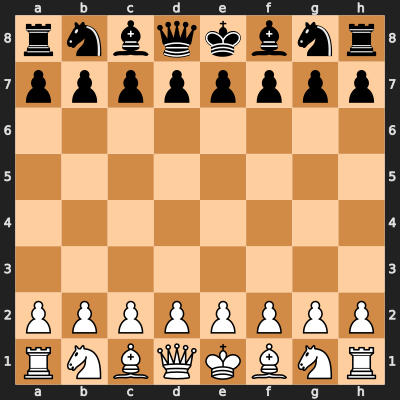

In [17]:
# Create a ChessAI instance that uses our model and token mapping
ai = ChessAI(model=model, token_to_id=token_to_id, id_to_token=id_to_token)

# Example: Starting position
start_fen = "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1"
display(SVG(chess.svg.board(chess.Board(start_fen), size=400)))

In [18]:
# Test sampling with different temperatures
print("Temperature = 0.5 (More conservative):")
move_conservative = ai.predict_full_move_with_sampling(start_fen, temperature=0.5, verbose=True)
print(f"\nFinal move: {move_conservative}\n")

print("Temperature = 1.0 (Balanced):")
move_balanced = ai.predict_full_move_with_sampling(start_fen, temperature=1.0, verbose=True)
print(f"\nFinal move: {move_balanced}\n")

print("Temperature = 1.5 (More creative/random):")
move_creative = ai.predict_full_move_with_sampling(start_fen, temperature=1.5, verbose=True)
print(f"\nFinal move: {move_creative}")

Temperature = 0.5 (More conservative):
Attempt 1/5
Invalid from square prediction: t_d7
Attempt 2/5
Predicted from square: f8
Invalid to square prediction: f_d3
Attempt 3/5
Invalid from square prediction: t_c6
Attempt 4/5
Predicted from square: b2
Invalid to square prediction: f_a6
Attempt 5/5
Invalid from square prediction: t_a5
No legal move found after 5 attempts. Using random move: d2d3

Final move: d2d3

Temperature = 1.0 (Balanced):
Attempt 1/5
Invalid from square prediction: t_h2
Attempt 2/5
Invalid from square prediction: t_e7
Attempt 3/5
Invalid from square prediction: t_c6
Attempt 4/5
Predicted from square: d8
Invalid to square prediction: f_f2
Attempt 5/5
Invalid from square prediction: t_d7
Attempt 2/5
Predicted from square: f8
Invalid to square prediction: f_d3
Attempt 3/5
Invalid from square prediction: t_c6
Attempt 4/5
Predicted from square: b2
Invalid to square prediction: f_a6
Attempt 5/5
Invalid from square prediction: t_a5
No legal move found after 5 attempts. Using 

## Interactive Play Loop

Play multiple moves against the AI with a continuous loop interface.

In [19]:
def interactive_chess_game(model, token_to_id, id_to_token, play_as='white', temperature=0.8):
    """
    Play a continuous chess game against the AI.
    
    Args:
        model: The ChessModel to use
        token_to_id: Token to ID mapping
        id_to_token: ID to token mapping
        play_as: 'white' or 'black' - which side the human plays
        temperature: Sampling temperature for AI moves
    """
    ai_white = play_as.lower() != 'white'
    ai_black = play_as.lower() != 'black'
    
    game = setup_game_from_notebook(
        model=model,
        token_to_id=token_to_id,
        id_to_token=id_to_token,
        ai_white=ai_white,
        ai_black=ai_black
    )
    
    game.display()
    
    # If AI plays white, it goes first
    if ai_white and game.board.turn == chess.WHITE:
        print("AI (White) makes the first move:")
        ai_move = game.get_ai_move(game.white_ai, temperature=temperature)
        if ai_move:
            game.make_move(ai_move)
        game.display()
    
    # Game loop
    while not game.board.is_game_over():
        # Determine if it's human's or AI's turn
        is_human_turn = (game.board.turn == chess.WHITE and play_as.lower() == 'white') or \
                        (game.board.turn == chess.BLACK and play_as.lower() == 'black')
        
        if is_human_turn:
            # Human turn
            color = "White" if game.board.turn == chess.WHITE else "Black"
            move = input(f"Your move ({color}), UCI format (e.g. 'e2e4') or 'quit': ")
            
            if move.lower() in ['quit', 'exit', 'q']:
                print("Game aborted.")
                break
                
            success = game.make_move(move)
            if not success:
                print("Invalid move. Try again.")
                continue
        else:
            # AI turn
            current_ai = game.white_ai if game.board.turn == chess.WHITE else game.black_ai
            ai_move = game.get_ai_move(current_ai, temperature=temperature)
            
            if not ai_move:
                print("AI couldn't find a legal move. Game terminated.")
                break
                
            game.make_move(ai_move)
        
        # Display the board after each move
        game.display()
        
        # Check if game is over
        if game.board.is_game_over():
            if game.board.is_checkmate():
                winner = "White" if game.board.turn == chess.BLACK else "Black"
                print(f"{winner} wins by checkmate!")
            elif game.board.is_stalemate():
                print("Game drawn by stalemate!")
            elif game.board.is_insufficient_material():
                print("Game drawn due to insufficient material!")
            elif game.board.is_fifty_moves():
                print("Game drawn by fifty-move rule!")
            elif game.board.is_repetition():
                print("Game drawn by repetition!")
            break

# Start a game where you play as white against the AI
# Run this cell and then uncomment the next line to play interactively
# interactive_chess_game(model, token_to_id, id_to_token, play_as='white', temperature=0.8)

## Watch AI vs. AI

Watch a game where the AI plays against itself with different temperature settings for each side.

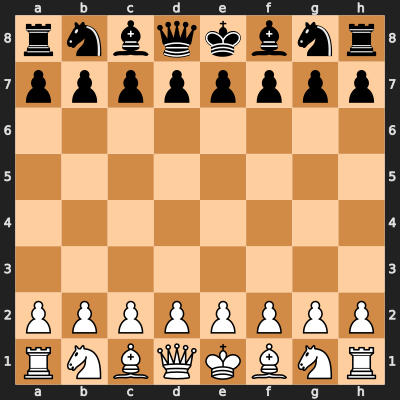

FEN: rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1
White's turn (AI)
AI plays: f2f3


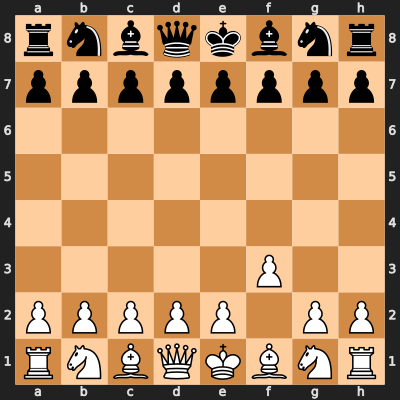

FEN: rnbqkbnr/pppppppp/8/8/8/5P2/PPPPP1PP/RNBQKBNR b KQkq - 0 1
Black's turn (AI)
AI plays: f7f5


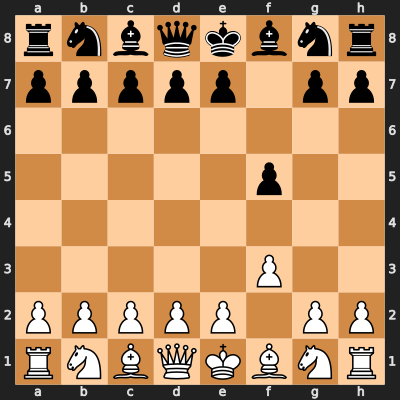

FEN: rnbqkbnr/ppppp1pp/8/5p2/8/5P2/PPPPP1PP/RNBQKBNR w KQkq - 0 2
White's turn (AI)
AI plays: g2g3
AI plays: g2g3


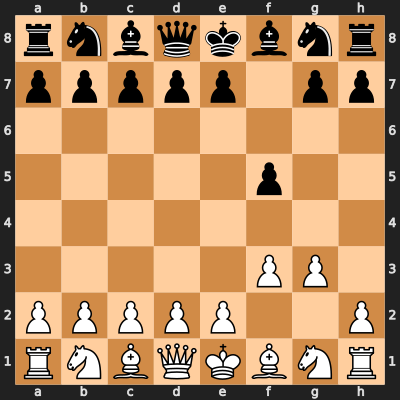

FEN: rnbqkbnr/ppppp1pp/8/5p2/8/5PP1/PPPPP2P/RNBQKBNR b KQkq - 0 2
Black's turn (AI)
AI plays: d7d5
AI plays: d7d5


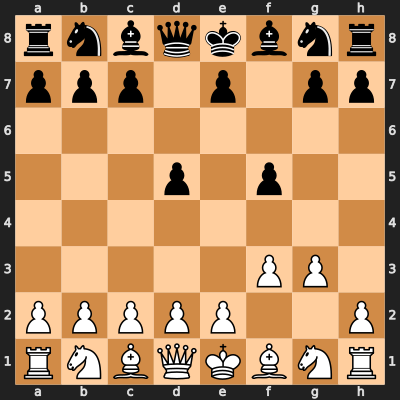

FEN: rnbqkbnr/ppp1p1pp/8/3p1p2/8/5PP1/PPPPP2P/RNBQKBNR w KQkq - 0 3
White's turn (AI)
AI plays: f3f4
AI plays: f3f4


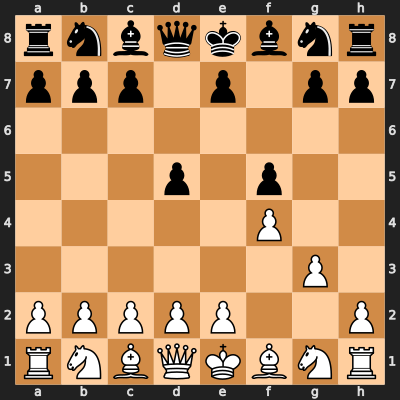

FEN: rnbqkbnr/ppp1p1pp/8/3p1p2/5P2/6P1/PPPPP2P/RNBQKBNR b KQkq - 0 3
Black's turn (AI)
AI plays: g7g5


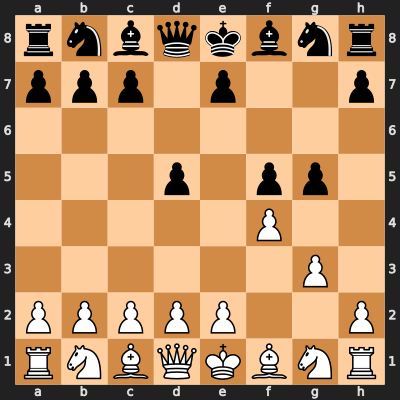

FEN: rnbqkbnr/ppp1p2p/8/3p1pp1/5P2/6P1/PPPPP2P/RNBQKBNR w KQkq - 0 4
White's turn (AI)
AI plays: h2h4
AI plays: h2h4


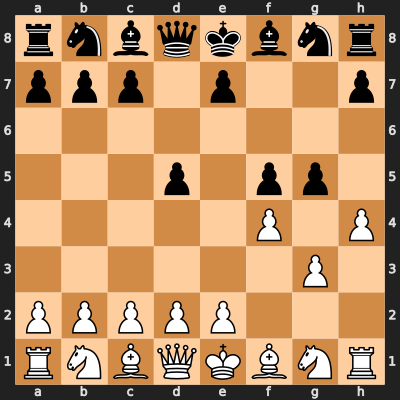

FEN: rnbqkbnr/ppp1p2p/8/3p1pp1/5P1P/6P1/PPPPP3/RNBQKBNR b KQkq - 0 4
Black's turn (AI)
AI plays: f8g7
AI plays: f8g7


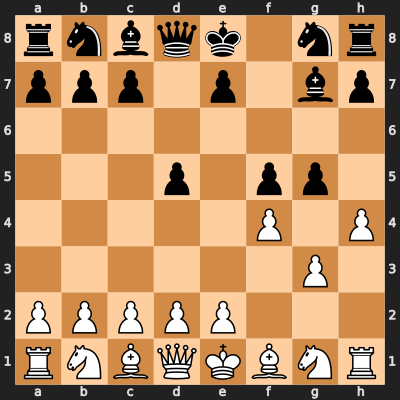

FEN: rnbqk1nr/ppp1p1bp/8/3p1pp1/5P1P/6P1/PPPPP3/RNBQKBNR w KQkq - 1 5
White's turn (AI)
AI plays: h4g5
AI plays: h4g5


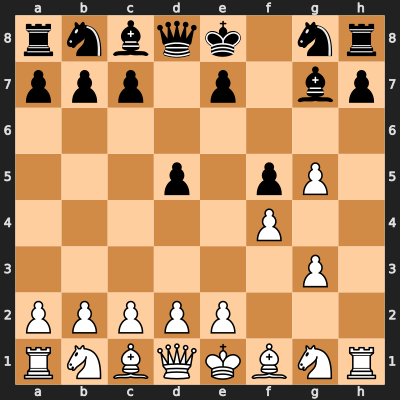

FEN: rnbqk1nr/ppp1p1bp/8/3p1pP1/5P2/6P1/PPPPP3/RNBQKBNR b KQkq - 0 5
Black's turn (AI)
AI plays: c7c5
AI plays: c7c5


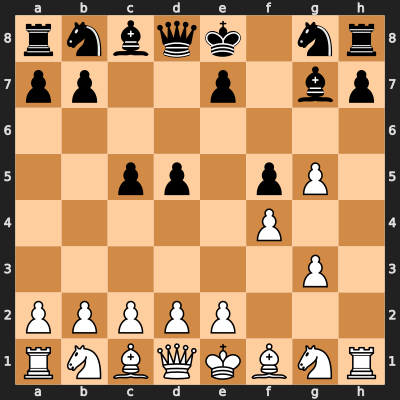

FEN: rnbqk1nr/pp2p1bp/8/2pp1pP1/5P2/6P1/PPPPP3/RNBQKBNR w KQkq - 0 6
Game stopped after 10 moves.


{'result': '*',
 'moves': ['f2f3',
  'f7f5',
  'g2g3',
  'd7d5',
  'f3f4',
  'g7g5',
  'h2h4',
  'f8g7',
  'h4g5',
  'c7c5'],
 'final_fen': 'rnbqk1nr/pp2p1bp/8/2pp1pP1/5P2/6P1/PPPPP3/RNBQKBNR w KQkq - 0 6',
 'move_count': 10}

In [20]:
# Create a game where AI plays against itself
ai_vs_ai = setup_game_from_notebook(
    model=model,
    token_to_id=token_to_id,
    id_to_token=id_to_token,
    ai_white=True,
    ai_black=True
)

# Play a full game with different temperatures for each side
# This will play only 10 moves (5 for each side)
ai_vs_ai.ai_vs_ai_game(max_moves=10, white_temp=0.7, black_temp=1.2)

## Comparing Before and After Training

Let's compare the model's performance before and after training.

In [ ]:
def compare_model_versions(original_state, current_model, token_to_id, id_to_token):
    """Compare moves suggested by different versions of the model"""
    # Create a temporary model with the original state
    original_model = ChessModel(
        num_tokens=MODEL_PARAMS['num_tokens'],
        num_classes=MODEL_PARAMS['num_classes'],
        d_model=MODEL_PARAMS['d_model'],
        nhead=MODEL_PARAMS['nhead'],
        num_layers=MODEL_PARAMS['num_layers'],
        dropout=MODEL_PARAMS['dropout']
    ).to(DEVICE)
    original_model.load_state_dict(original_state)
    original_model.eval()
    
    # Create AIs with both models
    original_ai = ChessAI(model=original_model, token_to_id=token_to_id, id_to_token=id_to_token)
    trained_ai = ChessAI(model=current_model, token_to_id=token_to_id, id_to_token=id_to_token)
    
    # Define positions to test
    test_positions = [
        "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1",  # Starting position
        "rnbqkbnr/pppp1ppp/8/4p3/4P3/8/PPPP1PPP/RNBQKBNR w KQkq - 0 2",  # After 1.e4 e5
        "r1bqkbnr/pppp1ppp/2n5/4p3/4P3/5N2/PPPP1PPP/RNBQKB1R w KQkq - 2 3"  # King's Knight Opening
    ]
    
    for i, fen in enumerate(test_positions):
        print(f"\nPosition {i+1}:")
        board = chess.Board(fen)
        display(SVG(chess.svg.board(board=board, size=400)))
        print(f"FEN: {fen}")
        
        # Get moves from both AIs
        print("\nPredictions (Temperature = 0.5):")
        original_move = original_ai.predict_full_move_with_sampling(fen, temperature=0.5)
        trained_move = trained_ai.predict_full_move_with_sampling(fen, temperature=0.5)
        
        print(f"Before training: {original_move}")
        print(f"After training:  {trained_move}")

# If we've done training, compare the original and trained models
if 'original_state' in globals():
    compare_model_versions(original_state, model, token_to_id, id_to_token)
else:
    print("No training has been performed to compare results.")